In [2]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis

In [3]:
# Load your data
data = pd.read_excel(r"D:\BioLab\Current_experiments\2005.04.17_mitahondria_analysis\analysis_gpt.xlsx")
data

,Mice age in month,Treatment,Biological Replicated,Cell area area in pixels,Mitochondria total intensity in 3 layers,Mitochondria intensity per pixel,Mitochondria intensity per pixel no background
0,12,CNT,1,4593,27382271,1987.246607,1287.246607
1,12,CNT,1,2440,11467621,1566.614891,866.614891
2,12,CNT,1,5740,26628471,1546.368815,846.368815
3,12,CNT,1,3511,13231873,1256.230229,556.230229
4,12,CNT,1,6274,26783873,1423.008873,723.008873
...,...,...,...,...,...,...,...
4690,5,LIV,2,3011,10149480,1123.600133,973.600133
4691,5,LIV,2,6496,13114355,672.945146,522.945146
4692,5,LIV,2,11334,49941679,1468.786513,1318.786513
4693,5,LIV,2,3952,16548423,1395.784666,1245.784666


C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: User

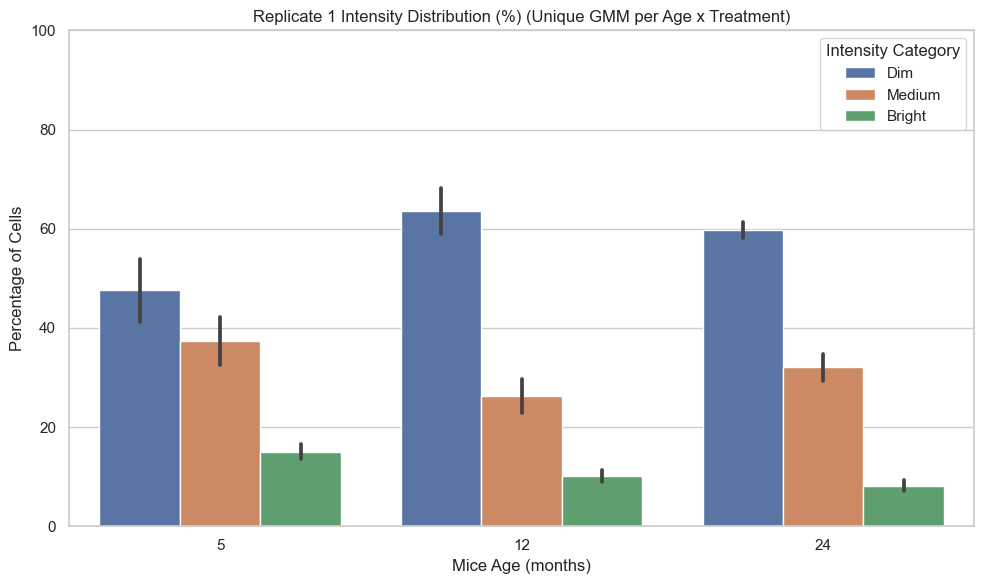

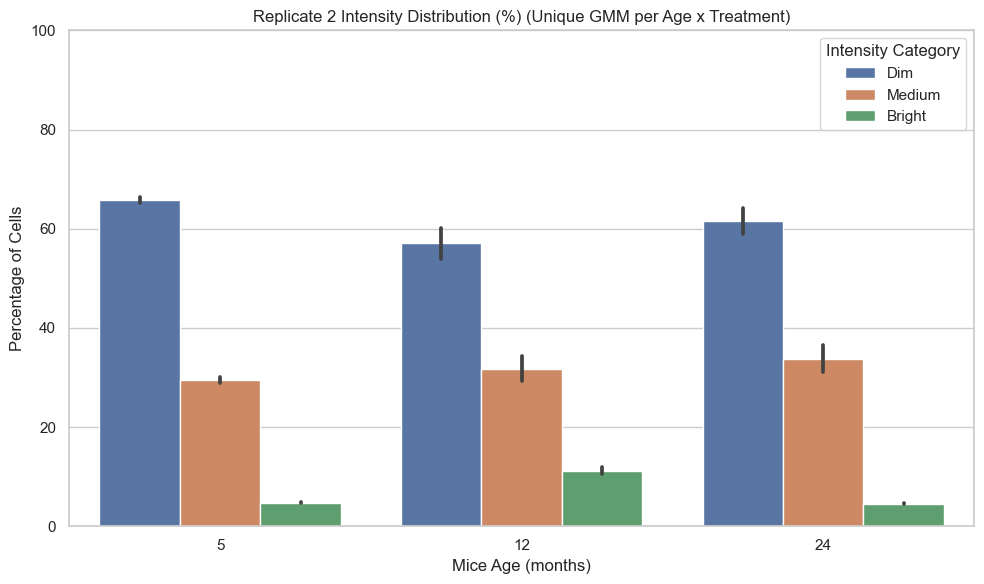

In [15]:

# Custom category order
category_order = ['Dim', 'Medium', 'Bright']

# Container for plot data
plot_data_all = []

# Cluster each (replicate, treatment, age) group separately
for replicate in [1, 2]:
    for treatment in ['CNT', 'LIV']:
        for age in sorted(data['Mice age in month'].unique()):
            # Filter group
            group = data[
                (data['Biological Replicated'] == replicate) &
                (data['Treatment'] == treatment) &
                (data['Mice age in month'] == age)
            ].copy()

            if group.empty:
                continue

            # Normalize within group
            scaler = StandardScaler()
            group['Normalized Intensity'] = scaler.fit_transform(group[['Mitochondria intensity per pixel no background']])

            # GMM clustering (3 groups)
            gmm = GaussianMixture(n_components=3, random_state=42)
            group['Cluster'] = gmm.fit_predict(group[['Normalized Intensity']])

            # Label clusters based on intensity means
            means = group.groupby('Cluster')['Mitochondria intensity per pixel no background'].mean().sort_values()
            labels = {means.index[0]: 'Dim', means.index[1]: 'Medium', means.index[2]: 'Bright'}
            group['Intensity Category ML'] = group['Cluster'].map(labels)
            group['Intensity Category ML'] = pd.Categorical(group['Intensity Category ML'], categories=category_order, ordered=True)

            # Calculate percentages
            percent = group['Intensity Category ML'].value_counts(normalize=True).reindex(category_order, fill_value=0) * 100

            for category in category_order:
                plot_data_all.append({
                    'Replicate': replicate,
                    'Mice age in month': age,
                    'Treatment': treatment,
                    'Intensity Category ML': category,
                    'Percent': percent[category]
                })

# Convert to DataFrame
plot_df = pd.DataFrame(plot_data_all)

# Plot results
sns.set(style="whitegrid")
for replicate in [1, 2]:
    plt.figure(figsize=(10, 6))
    subset = plot_df[plot_df['Replicate'] == replicate]
    sns.barplot(data=subset, x='Mice age in month', y='Percent', hue='Intensity Category ML', hue_order=category_order)
    plt.title(f'Replicate {replicate} Intensity Distribution (%) (Unique GMM per Age x Treatment)')
    plt.xlabel('Mice Age (months)')
    plt.ylabel('Percentage of Cells')
    plt.ylim(0, 100)
    plt.legend(title='Intensity Category')
    plt.tight_layout()
    plt.show()

C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nnina\miniconda3\envs\mal_env\lib\site-packages\sklearn\cluster\_kmeans.py:1436: User

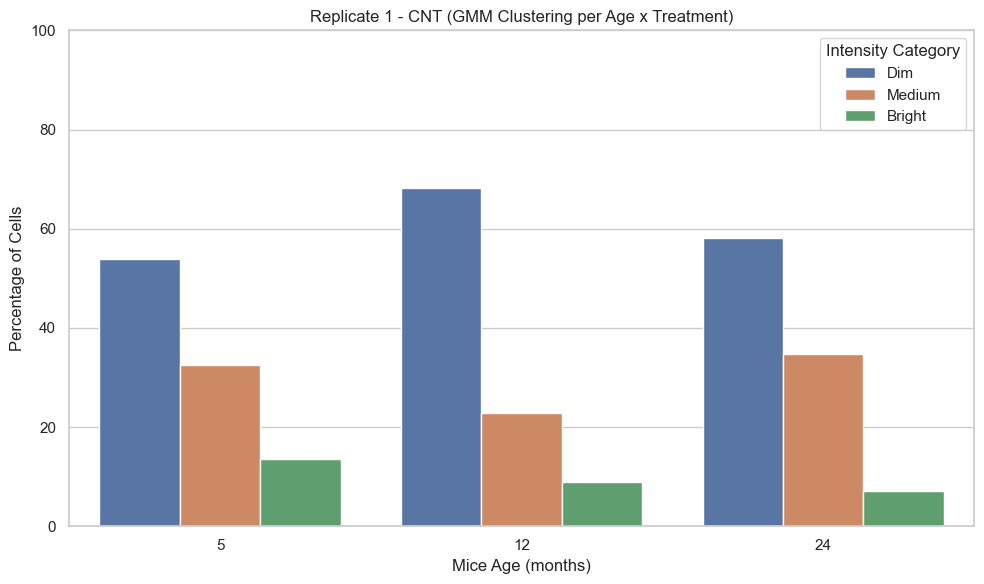

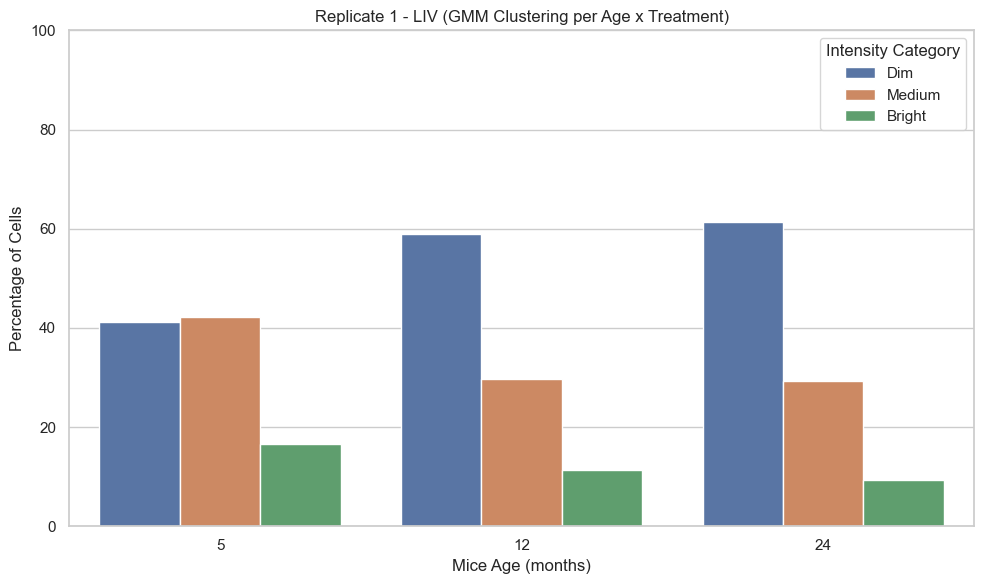

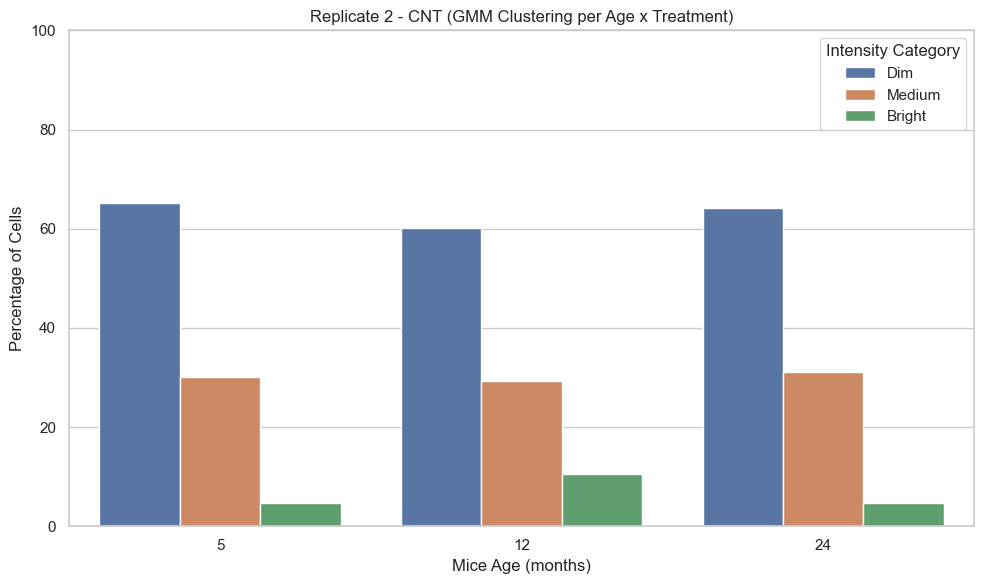

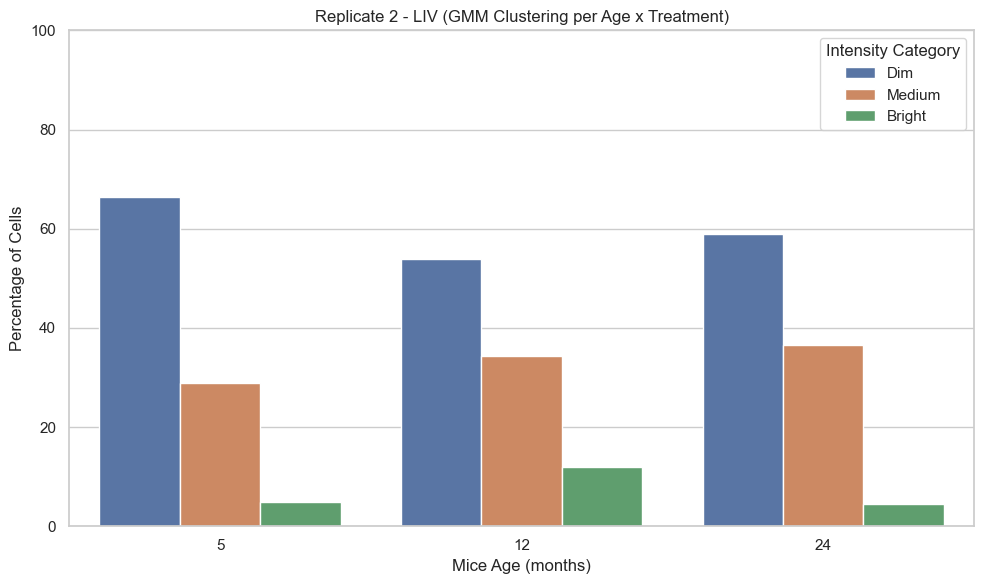

In [16]:
# Fixed order for plotting
category_order = ['Dim', 'Medium', 'Bright']

# Store plotting data
plot_data_all = []

# GMM clustering separately for each: replicate × treatment × age
for replicate in [1, 2]:
    for treatment in ['CNT', 'LIV']:
        for age in sorted(data['Mice age in month'].unique()):
            group = data[
                (data['Biological Replicated'] == replicate) &
                (data['Treatment'] == treatment) &
                (data['Mice age in month'] == age)
            ].copy()

            if group.empty:
                continue

            # Normalize intensity within group
            scaler = StandardScaler()
            group['Normalized Intensity'] = scaler.fit_transform(group[['Mitochondria intensity per pixel no background']])

            # Fit GMM with 3 clusters
            gmm = GaussianMixture(n_components=3, random_state=42)
            group['Cluster'] = gmm.fit_predict(group[['Normalized Intensity']])

            # Map clusters to labels based on intensity mean
            means = group.groupby('Cluster')['Mitochondria intensity per pixel no background'].mean().sort_values()
            labels = {means.index[0]: 'Dim', means.index[1]: 'Medium', means.index[2]: 'Bright'}
            group['Intensity Category ML'] = group['Cluster'].map(labels)
            group['Intensity Category ML'] = pd.Categorical(group['Intensity Category ML'], categories=category_order, ordered=True)

            # Compute percentage per class
            percent = group['Intensity Category ML'].value_counts(normalize=True).reindex(category_order, fill_value=0) * 100

            for category in category_order:
                plot_data_all.append({
                    'Replicate': replicate,
                    'Treatment': treatment,
                    'Mice age in month': age,
                    'Intensity Category ML': category,
                    'Percent': percent[category]
                })

# Combine all into one DataFrame
plot_df = pd.DataFrame(plot_data_all)

# Plot: Separate for CNT and LIV by replicate
sns.set(style="whitegrid")

for replicate in [1, 2]:
    for treatment in ['CNT', 'LIV']:
        subset = plot_df[(plot_df['Replicate'] == replicate) & (plot_df['Treatment'] == treatment)]

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=subset,
            x='Mice age in month',
            y='Percent',
            hue='Intensity Category ML',
            hue_order=category_order
        )

        plt.title(f'Replicate {replicate} - {treatment} (GMM Clustering per Age x Treatment)')
        plt.xlabel('Mice Age (months)')
        plt.ylabel('Percentage of Cells')
        plt.ylim(0, 100)
        plt.legend(title='Intensity Category')
        plt.tight_layout()
        plt.show()
